In [14]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from Bio.PDB.MMCIF2Dict import MMCIF2Dict
from matplotlib.collections import LineCollection

# AF3 models

In [15]:
json_file = "../AF3_model/ATP_bound/fold_fadsynthase_atp_2026_04_09_full_data_0.json"
cif_file  = "../AF3_model/ATP_bound/fold_fadsynthase_atp_2026_04_09_model_0.cif"

# --- load AF3 JSON ---
with open(json_file, "r") as f:
    af3 = json.load(f)

atom_plddts = np.asarray(af3["atom_plddts"], dtype=float)
print(f"Loaded {len(atom_plddts)} per-atom pLDDT values")

# --- load mmCIF atom table ---
from Bio.PDB.MMCIF2Dict import MMCIF2Dict
import pandas as pd
import numpy as np

cif = MMCIF2Dict(cif_file)

atom_df = pd.DataFrame({
    "group_PDB":   cif["_atom_site.group_PDB"],
    "atom_id":     pd.to_numeric(cif["_atom_site.id"], errors="coerce"),
    "atom_name":   cif["_atom_site.label_atom_id"],
    "resname":     cif["_atom_site.label_comp_id"],
    "chain_id":    cif["_atom_site.label_asym_id"],
    "seq_id":      pd.to_numeric(cif["_atom_site.label_seq_id"], errors="coerce"),
    "auth_seq_id": pd.to_numeric(cif["_atom_site.auth_seq_id"], errors="coerce"),
})

atom_df.head()

# Sanity check: AF3 per-atom pLDDT array should align with mmCIF atom rows
assert len(atom_df) == len(atom_plddts), (
    f"Length mismatch: mmCIF has {len(atom_df)} atoms, "
    f"JSON has {len(atom_plddts)} pLDDT values"
)

# Attach pLDDT to each atom row
atom_df["plddt"] = atom_plddts
atom_df.head()

# --- keep only alpha carbons from polymer ATOM records ---
# This excludes ligands / waters / most non-polymer stuff automatically.
ca_df = atom_df[
    (atom_df["group_PDB"] == "ATOM") &
    (atom_df["atom_name"] == "CA")
].copy()

print(f"Selected {len(ca_df)} CA atoms / residues")
ca_df.head()

Loaded 2631 per-atom pLDDT values
Selected 338 CA atoms / residues


,group_PDB,atom_id,atom_name,resname,chain_id,seq_id,auth_seq_id,plddt
1,ATOM,2,CA,MET,A,1.0,1,97.72
9,ATOM,10,CA,ASP,A,2.0,2,98.23
17,ATOM,18,CA,ILE,A,3.0,3,98.59
25,ATOM,26,CA,TRP,A,4.0,4,98.65
39,ATOM,40,CA,TYR,A,5.0,5,98.31


In [16]:
# If you want residue numbering from the structure:
x = ca_df["auth_seq_id"].to_numpy()
y = ca_df["plddt"].to_numpy()
chains = ca_df["chain_id"].to_numpy()

In [17]:
def af_plddt_color(plddt):
    """
    AlphaFold-style pLDDT colors:
      < 50   : orange
      50-70  : yellow
      70-90  : light blue
      > 90   : dark blue
    """
    if plddt < 50:
        return "#FF7D45"   # very low
    elif plddt < 70:
        return "#FFDB13"   # low
    elif plddt < 90:
        return "#65CBF3"   # confident
    else:
        return "#0053D6"   # very high

point_colors = [af_plddt_color(v) for v in y]

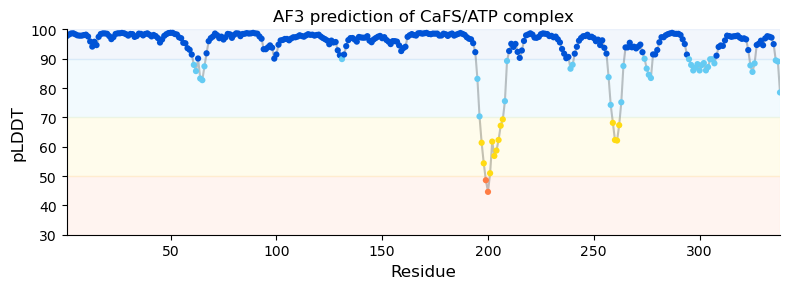

In [18]:
fig, ax = plt.subplots(figsize=(8, 3))

ax.plot(x, y, color="0.75", lw=1.5, zorder=1)
ax.scatter(x, y, c=point_colors, s=20, edgecolor="none", zorder=2)

# confidence bands
ax.axhspan(0, 50, color="#FF7D45", alpha=0.08)
ax.axhspan(50, 70, color="#FFDB13", alpha=0.08)
ax.axhspan(70, 90, color="#65CBF3", alpha=0.08)
ax.axhspan(90, 100, color="#0053D6", alpha=0.05)

# chain boundaries
for i in range(1, len(ca_df)):
    if chains[i] != chains[i - 1]:
        ax.axvline(x[i], color="0.5", ls="--", lw=1)

ax.set_xlim(x.min(), x.max())
ax.set_ylim(30, 100)
ax.set_xlabel("Residue", fontsize=12)
ax.set_ylabel("pLDDT", fontsize=12)
ax.set_title("AF3 prediction of CaFS/ATP complex")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig('ATP_bound_pLDDT.png')
plt.show()

## *ca*FS bound with FAD

In [19]:
json_file = "../AF3_model/FAD_bound/fold_2026_04_10_08_26_full_data_0.json"
cif_file  = "../AF3_model/FAD_bound/fold_2026_04_10_08_26_model_0.cif"

# --- load AF3 JSON ---
with open(json_file, "r") as f:
    af3 = json.load(f)

atom_plddts = np.asarray(af3["atom_plddts"], dtype=float)
print(f"Loaded {len(atom_plddts)} per-atom pLDDT values")

# --- load mmCIF atom table ---
from Bio.PDB.MMCIF2Dict import MMCIF2Dict
import pandas as pd
import numpy as np

cif = MMCIF2Dict(cif_file)

atom_df = pd.DataFrame({
    "group_PDB":   cif["_atom_site.group_PDB"],
    "atom_id":     pd.to_numeric(cif["_atom_site.id"], errors="coerce"),
    "atom_name":   cif["_atom_site.label_atom_id"],
    "resname":     cif["_atom_site.label_comp_id"],
    "chain_id":    cif["_atom_site.label_asym_id"],
    "seq_id":      pd.to_numeric(cif["_atom_site.label_seq_id"], errors="coerce"),
    "auth_seq_id": pd.to_numeric(cif["_atom_site.auth_seq_id"], errors="coerce"),
})

atom_df.head()

# Sanity check: AF3 per-atom pLDDT array should align with mmCIF atom rows
assert len(atom_df) == len(atom_plddts), (
    f"Length mismatch: mmCIF has {len(atom_df)} atoms, "
    f"JSON has {len(atom_plddts)} pLDDT values"
)

# Attach pLDDT to each atom row
atom_df["plddt"] = atom_plddts
atom_df.head()

# --- keep only alpha carbons from polymer ATOM records ---
# This excludes ligands / waters / most non-polymer stuff automatically.
ca_df = atom_df[
    (atom_df["group_PDB"] == "ATOM") &
    (atom_df["atom_name"] == "CA")
].copy()

print(f"Selected {len(ca_df)} CA atoms / residues")
ca_df.head()

Loaded 2653 per-atom pLDDT values
Selected 338 CA atoms / residues


,group_PDB,atom_id,atom_name,resname,chain_id,seq_id,auth_seq_id,plddt
1,ATOM,2,CA,MET,A,1.0,1,97.67
9,ATOM,10,CA,ASP,A,2.0,2,98.11
17,ATOM,18,CA,ILE,A,3.0,3,98.30
25,ATOM,26,CA,TRP,A,4.0,4,98.40
39,ATOM,40,CA,TYR,A,5.0,5,97.62


In [20]:
# If you want residue numbering from the structure:
x = ca_df["auth_seq_id"].to_numpy()
y = ca_df["plddt"].to_numpy()
chains = ca_df["chain_id"].to_numpy()

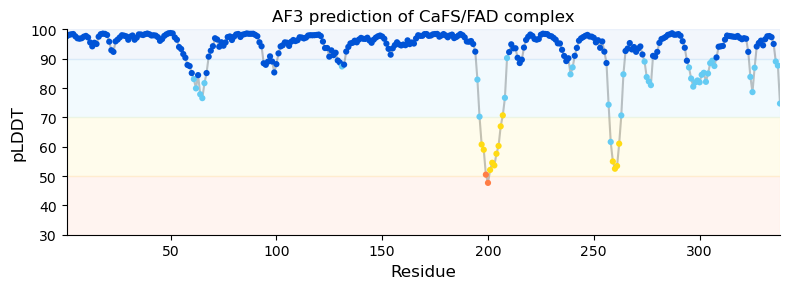

In [21]:




fig, ax = plt.subplots(figsize=(8, 3))

ax.plot(x, y, color="0.75", lw=1.5, zorder=1)
ax.scatter(x, y, c=point_colors, s=20, edgecolor="none", zorder=2)

# confidence bands
ax.axhspan(0, 50, color="#FF7D45", alpha=0.08)
ax.axhspan(50, 70, color="#FFDB13", alpha=0.08)
ax.axhspan(70, 90, color="#65CBF3", alpha=0.08)
ax.axhspan(90, 100, color="#0053D6", alpha=0.05)

# chain boundaries
for i in range(1, len(ca_df)):
    if chains[i] != chains[i - 1]:
        ax.axvline(x[i], color="0.5", ls="--", lw=1)

ax.set_xlim(x.min(), x.max())
ax.set_ylim(30, 100)
ax.set_xlabel("Residue", fontsize=12)
ax.set_ylabel("pLDDT", fontsize=12)
ax.set_title("AF3 prediction of CaFS/FAD complex")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig('FAD_bound_pLDDT.png')
plt.show()

# Boltz-2 structures

## *ca*FS bound with ATP

In [28]:
import numpy as np

def get_ca_bfactors_pdb(pdb_file):
    bfactors = []
    
    with open(pdb_file, "r") as f:
        for line in f:
            if line.startswith("ATOM"):
                atom_name = line[12:16].strip()
                
                if atom_name == "CA":
                    bfactor = float(line[60:66])
                    bfactors.append(bfactor)
    
    return np.array(bfactors)

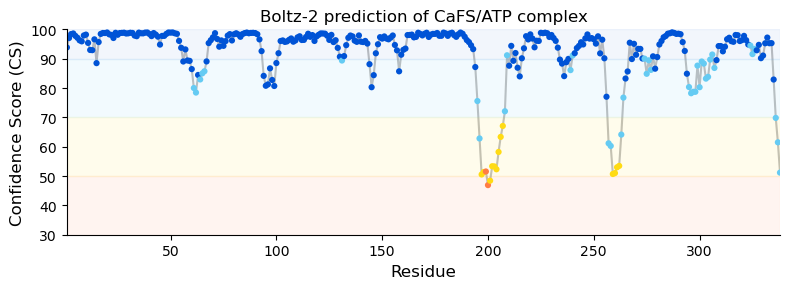

In [31]:
boltz_ATP_pdb = '../Boltz2_model/ATP_bound.pdb'
y = get_ca_bfactors_pdb(boltz_ATP_pdb)


fig, ax = plt.subplots(figsize=(8, 3))

ax.plot(x, y, color="0.75", lw=1.5, zorder=1)
ax.scatter(x, y, c=point_colors, s=20, edgecolor="none", zorder=2)

# confidence bands
ax.axhspan(0, 50, color="#FF7D45", alpha=0.08)
ax.axhspan(50, 70, color="#FFDB13", alpha=0.08)
ax.axhspan(70, 90, color="#65CBF3", alpha=0.08)
ax.axhspan(90, 100, color="#0053D6", alpha=0.05)

# chain boundaries
for i in range(1, len(ca_df)):
    if chains[i] != chains[i - 1]:
        ax.axvline(x[i], color="0.5", ls="--", lw=1)

ax.set_xlim(x.min(), x.max())
ax.set_ylim(30, 100)
ax.set_xlabel("Residue", fontsize=12)
ax.set_ylabel("Confidence Score (CS)", fontsize=12)
ax.set_title("Boltz-2 prediction of CaFS/ATP complex")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig('Boltz2_ATP_bound_pLDDT.png')
plt.show()

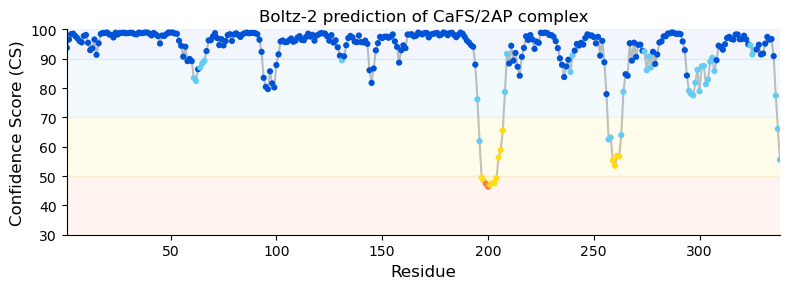

In [32]:
boltz_2AP_pdb = '../Boltz2_model/2AP_bound.pdb'
y = get_ca_bfactors_pdb(boltz_2AP_pdb)


fig, ax = plt.subplots(figsize=(8, 3))

ax.plot(x, y, color="0.75", lw=1.5, zorder=1)
ax.scatter(x, y, c=point_colors, s=20, edgecolor="none", zorder=2)

# confidence bands
ax.axhspan(0, 50, color="#FF7D45", alpha=0.08)
ax.axhspan(50, 70, color="#FFDB13", alpha=0.08)
ax.axhspan(70, 90, color="#65CBF3", alpha=0.08)
ax.axhspan(90, 100, color="#0053D6", alpha=0.05)

# chain boundaries
for i in range(1, len(ca_df)):
    if chains[i] != chains[i - 1]:
        ax.axvline(x[i], color="0.5", ls="--", lw=1)

ax.set_xlim(x.min(), x.max())
ax.set_ylim(30, 100)
ax.set_xlabel("Residue", fontsize=12)
ax.set_ylabel("Confidence Score (CS)", fontsize=12)
ax.set_title("Boltz-2 prediction of CaFS/2AP complex")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig('Boltz2_2AP_bound_pLDDT.png')
plt.show()